# RAG Ablation Study — Publication-Quality Plots
**MSc Project: Trustworthy SLMs for Ambient Clinical Scribing**

Generates three figures from Table C (RAG ablation .md file):
- **Figure A**: Overall metrics grouped bar chart (ROUGE-L, MEDCON-F1, Judge Avg)
- **Figure B**: Per-section ROUGE-L heatmap across models and RAG configs
- **Figure C**: Delta plot — gain over Dense Only baseline per model


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Consistent style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA — transcribed exactly from table_c_rag_ablation.md
# ══════════════════════════════════════════════════════════════════════════════

MODELS   = ['Phi-3.5 (3.8B)', 'Llama-3.2 (3B)', 'Llama-3.2 (1B)']
CONFIGS  = ['Dense Only', 'Dense+Rerank', 'Dense+Rerank+QE', 'Full Medical']
SECTIONS = ['Chief Complaint', 'HPI', 'Past Medical Hx', 'Medications',
            'Allergies', 'Examination', 'Assessment', 'Plan', 'Safety Netting']

# ── Overall metrics [model][config] ──────────────────────────────────────────
overall = {
    'ROUGE-L': {
        'Phi-3.5 (3.8B)':  [0.536, 0.627, 0.632, 0.632],
        'Llama-3.2 (3B)':  [0.626, 0.632, 0.636, 0.632],
        'Llama-3.2 (1B)':  [0.599, 0.596, 0.600, 0.595],
    },
    'ROUGE-1': {
        'Phi-3.5 (3.8B)':  [0.638, 0.729, 0.736, 0.736],
        'Llama-3.2 (3B)':  [0.736, 0.741, 0.743, 0.739],
        'Llama-3.2 (1B)':  [0.719, 0.715, 0.717, 0.716],
    },
    'BLEU-4': {
        'Phi-3.5 (3.8B)':  [0.266, 0.350, 0.363, 0.368],
        'Llama-3.2 (3B)':  [0.359, 0.363, 0.367, 0.364],
        'Llama-3.2 (1B)':  [0.333, 0.331, 0.337, 0.328],
    },
    'BERTScore': {
        'Phi-3.5 (3.8B)':  [0.923, 0.938, 0.940, 0.939],
        'Llama-3.2 (3B)':  [0.937, 0.938, 0.938, 0.939],
        'Llama-3.2 (1B)':  [0.936, 0.935, 0.935, 0.935],
    },
    'MEDCON-F1': {
        'Phi-3.5 (3.8B)':  [0.743, 0.765, 0.778, 0.767],
        'Llama-3.2 (3B)':  [0.788, 0.791, 0.800, 0.794],
        'Llama-3.2 (1B)':  [0.772, 0.774, 0.773, 0.766],
    },
    'Judge Avg': {
        'Phi-3.5 (3.8B)':  [4.33, 4.36, 4.43, 4.33],
        'Llama-3.2 (3B)':  [4.35, 4.33, 4.35, 4.31],
        'Llama-3.2 (1B)':  [4.15, 4.11, 4.09, 4.18],
    },
}

# Teacher reference (mean ± SD from 3 runs)
teacher = {
    'ROUGE-L':   (0.428, 0.004),
    'ROUGE-1':   (0.582, 0.004),
    'BLEU-4':    (0.163, 0.003),
    'BERTScore': (0.876, 0.000),
    'MEDCON-F1': (0.660, 0.003),
    'Judge Avg': (4.757, 0.006),
}

# ── Per-section ROUGE-L [model][config][section] ──────────────────────────────
section_rouge = {
    'Phi-3.5 (3.8B)': {
        'Dense Only':       [0.863, 0.456, 0.857, 0.884, 0.809, 0.620, 0.420, 0.411, 0.213],
        'Dense+Rerank':     [0.850, 0.507, 0.844, 0.882, 0.764, 0.661, 0.495, 0.489, 0.585],
        'Dense+Rerank+QE':  [0.849, 0.484, 0.877, 0.901, 0.784, 0.692, 0.524, 0.501, 0.589],
        'Full Medical':     [0.859, 0.513, 0.842, 0.902, 0.772, 0.685, 0.509, 0.509, 0.595],
    },
    'Llama-3.2 (3B)': {
        'Dense Only':       [0.837, 0.501, 0.793, 0.821, 0.845, 0.676, 0.467, 0.481, 0.598],
        'Dense+Rerank':     [0.836, 0.487, 0.849, 0.860, 0.856, 0.697, 0.489, 0.485, 0.606],
        'Dense+Rerank+QE':  [0.840, 0.503, 0.831, 0.858, 0.837, 0.697, 0.490, 0.497, 0.614],
        'Full Medical':     [0.841, 0.487, 0.853, 0.864, 0.846, 0.704, 0.492, 0.485, 0.605],
    },
    'Llama-3.2 (1B)': {
        'Dense Only':       [0.812, 0.441, 0.774, 0.833, 0.827, 0.671, 0.455, 0.463, 0.577],
        'Dense+Rerank':     [0.819, 0.443, 0.754, 0.840, 0.798, 0.675, 0.462, 0.476, 0.571],
        'Dense+Rerank+QE':  [0.814, 0.436, 0.773, 0.869, 0.817, 0.679, 0.508, 0.463, 0.575],
        'Full Medical':     [0.813, 0.432, 0.753, 0.825, 0.822, 0.668, 0.475, 0.460, 0.570],
    },
}

print('Data loaded. Models:', MODELS)
print('Configs:', CONFIGS)
print('Sections:', SECTIONS)

Data loaded. Models: ['Phi-3.5 (3.8B)', 'Llama-3.2 (3B)', 'Llama-3.2 (1B)']
Configs: ['Dense Only', 'Dense+Rerank', 'Dense+Rerank+QE', 'Full Medical']
Sections: ['Chief Complaint', 'HPI', 'Past Medical Hx', 'Medications', 'Allergies', 'Examination', 'Assessment', 'Plan', 'Safety Netting']


## Figure A — Overall Metrics: Grouped Bar Chart
Shows ROUGE-L, MEDCON-F1, and Judge Avg across models and RAG configs.
Teacher shown as horizontal dashed reference line.

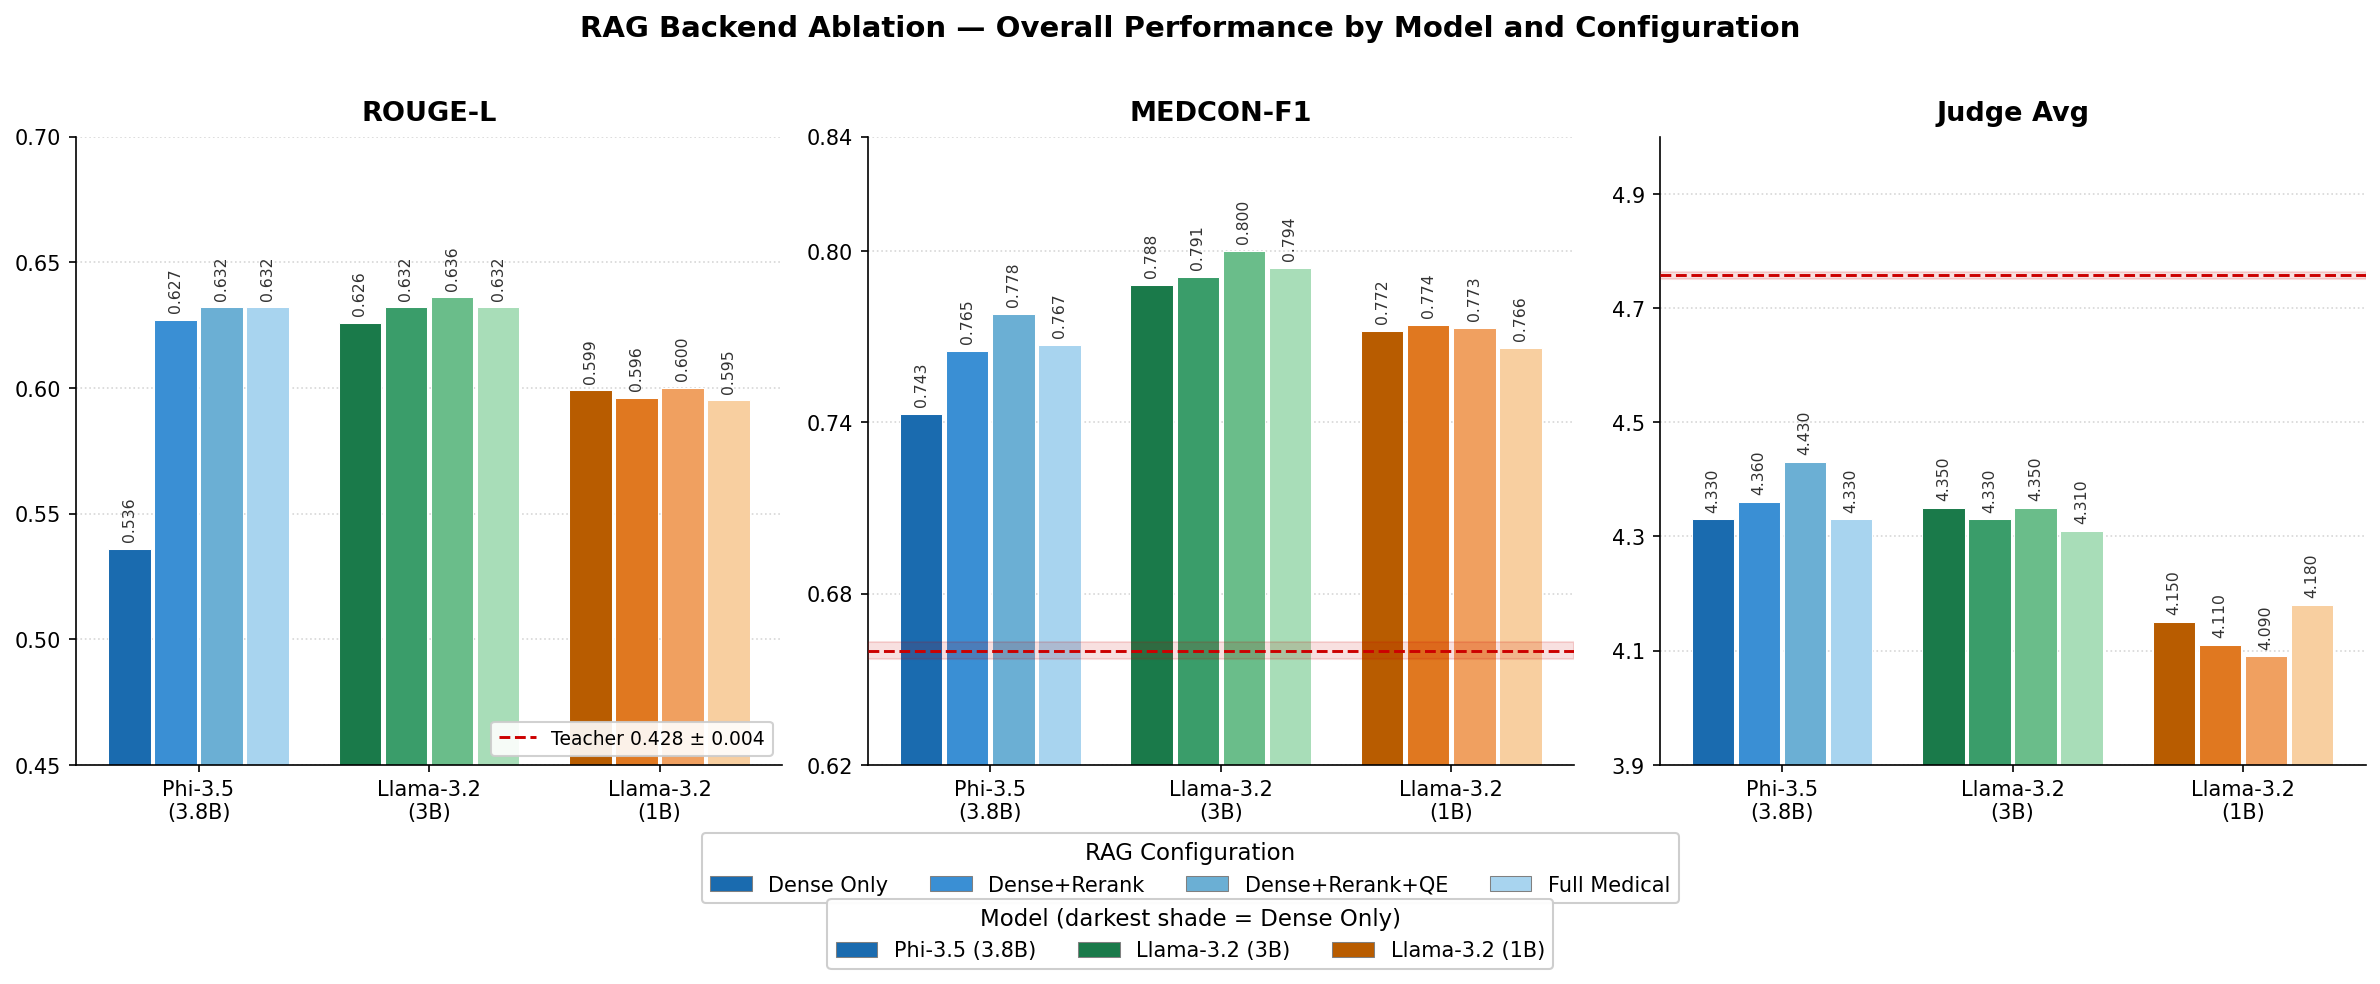

Saved: figure_A_overall_metrics.png


In [3]:
# Colour palette — model colours, config shades
MODEL_COLOURS = {
    'Phi-3.5 (3.8B)':  ['#1A6BAF', '#3A8FD4', '#6BAFD4', '#A8D4EF'],
    'Llama-3.2 (3B)':  ['#1A7A4A', '#3A9D6A', '#6ABD8A', '#A8DDB8'],
    'Llama-3.2 (1B)':  ['#B85C00', '#E07820', '#F0A060', '#F8CFA0'],
}

PLOT_METRICS = ['ROUGE-L', 'MEDCON-F1', 'Judge Avg']
YLIMS        = [(0.45, 0.70), (0.62, 0.84), (3.9, 5.0)]
YTICKS       = [
    [0.45, 0.50, 0.55, 0.60, 0.65, 0.70],
    [0.62, 0.68, 0.74, 0.80, 0.84],
    [3.9, 4.1, 4.3, 4.5, 4.7, 4.9],
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('RAG Backend Ablation — Overall Performance by Model and Configuration',
             fontsize=14, fontweight='bold', y=1.01)

n_models  = len(MODELS)
n_configs = len(CONFIGS)
group_w   = 0.8
bar_w     = group_w / n_configs

for ax, metric, ylim, yticks in zip(axes, PLOT_METRICS, YLIMS, YTICKS):
    for m_idx, model in enumerate(MODELS):
        colours = MODEL_COLOURS[model]
        for c_idx, config in enumerate(CONFIGS):
            val = overall[metric][model][c_idx]
            x   = m_idx + (c_idx - (n_configs - 1) / 2) * bar_w
            bar = ax.bar(x, val, width=bar_w * 0.92,
                         color=colours[c_idx],
                         edgecolor='white', linewidth=0.5)
            # Value label on bar
            ax.text(x, val + (ylim[1] - ylim[0]) * 0.012,
                    f'{val:.3f}', ha='center', va='bottom',
                    fontsize=7.5, color='#333333', rotation=90)

    # Teacher reference line
    t_mean, t_sd = teacher[metric]
    ax.axhline(t_mean, color='#CC0000', linestyle='--', linewidth=1.4,
               label=f'Teacher {t_mean:.3f} ± {t_sd:.3f}', zorder=5)
    ax.axhspan(t_mean - t_sd, t_mean + t_sd,
               alpha=0.12, color='#CC0000', zorder=4)

    ax.set_title(metric, fontweight='bold', pad=8)
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels([m.replace(' (', '\n(') for m in MODELS], fontsize=10)
    ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Legend for teacher line (first subplot only)
    if ax == axes[0]:
        ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

# Config colour legend (shared)
config_patches = [
    mpatches.Patch(color='#555555', alpha=1.0 - i*0.22,
                   label=c) for i, c in enumerate(CONFIGS)
]
# Use actual colours from Phi palette for legend
config_patches = [
    mpatches.Patch(facecolor=MODEL_COLOURS['Phi-3.5 (3.8B)'][i], label=c,
                   edgecolor='grey', linewidth=0.5)
    for i, c in enumerate(CONFIGS)
]
fig.legend(handles=config_patches, title='RAG Configuration',
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08),
           framealpha=0.95, fontsize=10)

# Model colour legend
model_patches = [
    mpatches.Patch(facecolor=MODEL_COLOURS[m][0], label=m,
                   edgecolor='grey', linewidth=0.5)
    for m in MODELS
]
fig.legend(handles=model_patches, title='Model (darkest shade = Dense Only)',
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.16),
           framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig('figure_A_overall_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure_A_overall_metrics.png')

## Figure B — Per-Section ROUGE-L Heatmap
9 clinical sections × 4 RAG configs × 3 models.
Reveals which sections are hard and where RAG helps most.

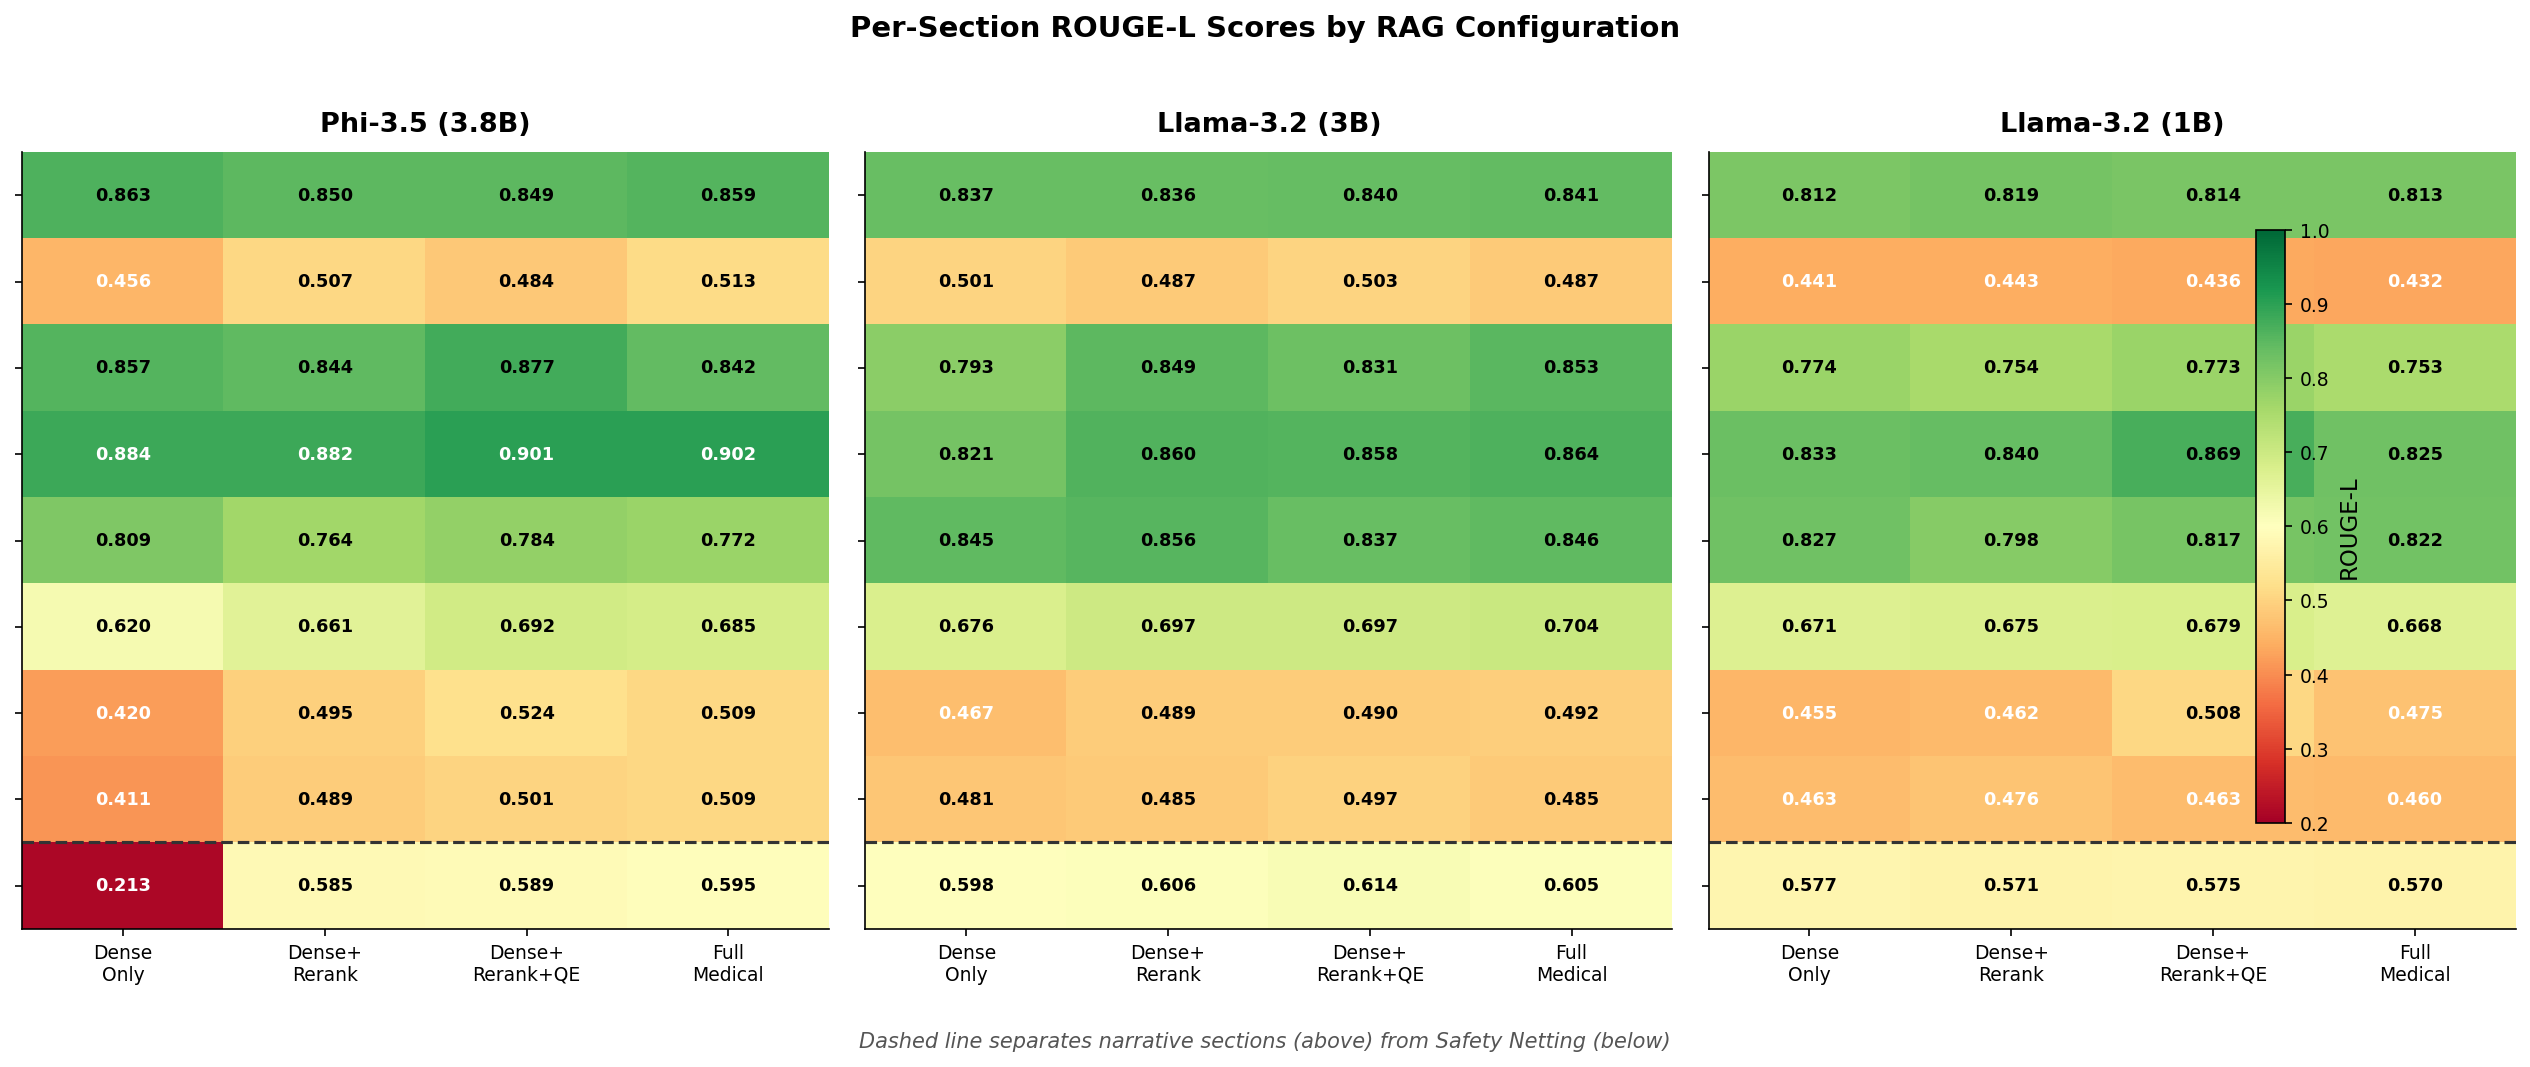

Saved: figure_B_section_heatmap.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6.5), sharey=True)
fig.suptitle('Per-Section ROUGE-L Scores by RAG Configuration',
             fontsize=14, fontweight='bold', y=1.02)

cmap = plt.cm.RdYlGn  # Red (low) → Yellow → Green (high)
vmin, vmax = 0.20, 1.00

for ax, model in zip(axes, MODELS):
    # Build matrix: rows=sections, cols=configs
    mat = np.array([
        [section_rouge[model][cfg][si] for cfg in CONFIGS]
        for si in range(len(SECTIONS))
    ])

    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    # Annotate each cell with value
    for r in range(len(SECTIONS)):
        for c in range(len(CONFIGS)):
            val  = mat[r, c]
            norm = (val - vmin) / (vmax - vmin)
            txt_col = 'white' if norm < 0.35 or norm > 0.85 else 'black'
            ax.text(c, r, f'{val:.3f}', ha='center', va='center',
                    fontsize=8.5, color=txt_col, fontweight='bold')

    ax.set_title(model, fontweight='bold', pad=10)
    ax.set_xticks(range(len(CONFIGS)))
    ax.set_xticklabels(
        ['Dense\nOnly', 'Dense+\nRerank', 'Dense+\nRerank+QE', 'Full\nMedical'],
        fontsize=9
    )
    ax.set_yticks(range(len(SECTIONS)))

    if ax == axes[0]:
        ax.set_yticklabels(SECTIONS, fontsize=10)
    else:
        ax.set_yticklabels([])

    # Horizontal separator line before Safety Netting
    ax.axhline(7.5, color='#333333', linewidth=1.5, linestyle='--')

# Shared colourbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('ROUGE-L', fontsize=11)
cbar.ax.tick_params(labelsize=9)

fig.text(0.5, -0.04,
         'Dashed line separates narrative sections (above) from Safety Netting (below)',
         ha='center', fontsize=10, style='italic', color='#555555')

plt.tight_layout()
plt.savefig('figure_B_section_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure_B_section_heatmap.png')

## Figure C — Delta Plot: Gain Over Dense Only Baseline
Shows how much each upgrade (Rerank, +QE, +Medical) improves ROUGE-L, MEDCON-F1, Judge Avg.
Makes the 1B model's plateau immediately visible.

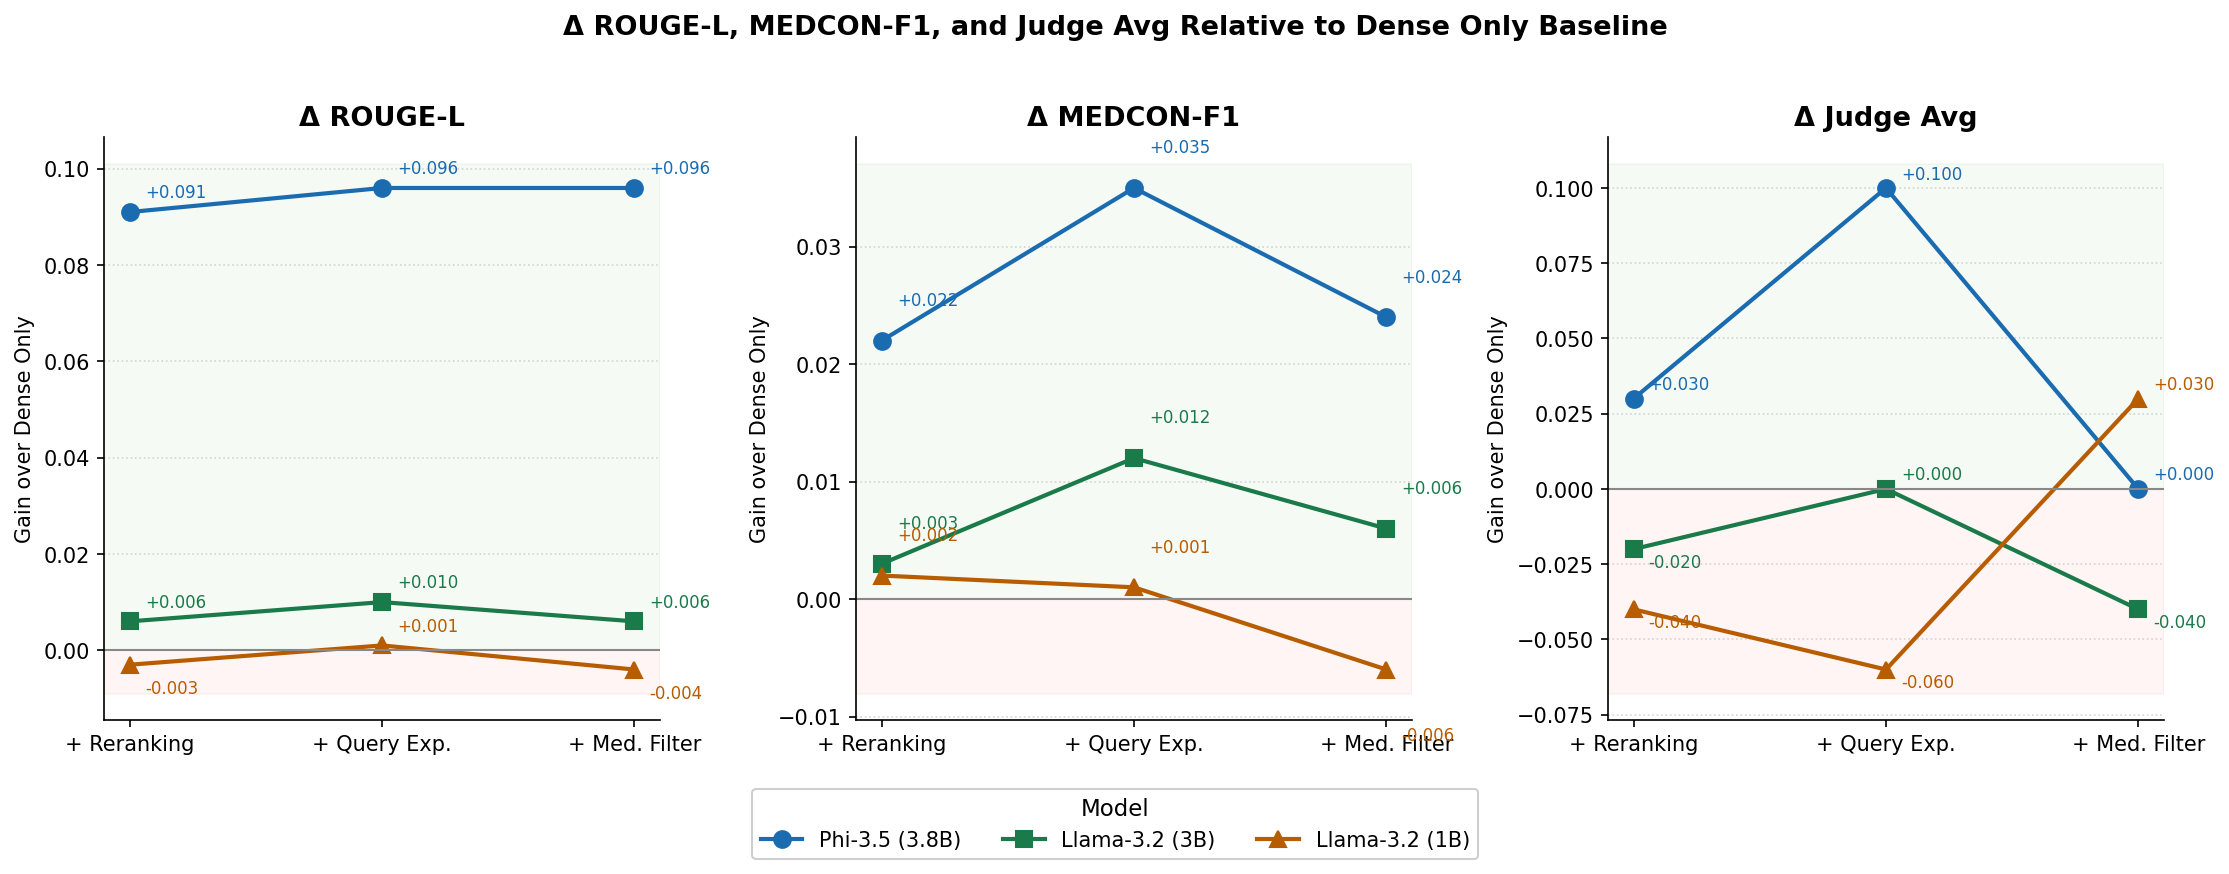

Saved: figure_C_delta_gains.png


In [5]:
DELTA_METRICS = ['ROUGE-L', 'MEDCON-F1', 'Judge Avg']
UPGRADE_CONFIGS = ['Dense+Rerank', 'Dense+Rerank+QE', 'Full Medical']
UPGRADE_LABELS  = ['+ Reranking', '+ Query Exp.', '+ Med. Filter']

MODEL_COLOURS_SOLID = {
    'Phi-3.5 (3.8B)':  '#1A6BAF',
    'Llama-3.2 (3B)':  '#1A7A4A',
    'Llama-3.2 (1B)':  '#B85C00',
}
MODEL_MARKERS = {
    'Phi-3.5 (3.8B)':  'o',
    'Llama-3.2 (3B)':  's',
    'Llama-3.2 (1B)':  '^',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle('Δ ROUGE-L, MEDCON-F1, and Judge Avg Relative to Dense Only Baseline',
             fontsize=13, fontweight='bold', y=1.02)

for ax, metric in zip(axes, DELTA_METRICS):
    for model in MODELS:
        baseline = overall[metric][model][0]  # Dense Only
        deltas   = [
            overall[metric][model][CONFIGS.index(cfg)] - baseline
            for cfg in UPGRADE_CONFIGS
        ]
        ax.plot([0, 1, 2], deltas,
                marker=MODEL_MARKERS[model],
                color=MODEL_COLOURS_SOLID[model],
                linewidth=2, markersize=8,
                label=model)
        # Annotate each point
        for xi, d in enumerate(deltas):
            offset = 0.003 if d >= 0 else -0.006
            ax.annotate(f'{d:+.3f}',
                        xy=(xi, d), xytext=(xi + 0.06, d + offset),
                        fontsize=8, color=MODEL_COLOURS_SOLID[model])

    ax.axhline(0, color='#888888', linewidth=1.0, linestyle='-')
    ax.set_title(f'Δ {metric}', fontweight='bold')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(UPGRADE_LABELS, fontsize=10)
    ax.set_ylabel('Gain over Dense Only', fontsize=10)
    ax.yaxis.grid(True, linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)

    # Shade gain / loss regions
    ylims = ax.get_ylim()
    ax.axhspan(0, ylims[1] if ylims[1] > 0 else 0.01,
               alpha=0.04, color='green', zorder=0)
    ax.axhspan(ylims[0] if ylims[0] < 0 else -0.001, 0,
               alpha=0.04, color='red', zorder=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Model',
           loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.12),
           framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig('figure_C_delta_gains.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure_C_delta_gains.png')

## Bonus: Safety Netting Deep-Dive Bar Chart
Highlights the dramatic RAG impact on the hardest clinical section.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))

sn_idx   = SECTIONS.index('Safety Netting')
x        = np.arange(len(CONFIGS))
bar_w    = 0.24
offsets  = [-bar_w, 0, bar_w]

for model, offset in zip(MODELS, offsets):
    vals = [section_rouge[model][cfg][sn_idx] for cfg in CONFIGS]
    bars = ax.bar(x + offset, vals, width=bar_w * 0.9,
                  color=MODEL_COLOURS_SOLID[model],
                  label=model, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.008,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=8.5, color='#333333')

ax.set_title('Safety Netting Section — ROUGE-L by RAG Configuration',
             fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(CONFIGS, fontsize=10)
ax.set_ylabel('ROUGE-L', fontsize=11)
ax.set_ylim(0.15, 0.72)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc='upper left')

# Annotate Phi-3.5 Dense Only as critical failure
ax.annotate('Critical failure\n(0.213)',
            xy=(-bar_w, 0.213), xytext=(-bar_w + 0.05, 0.30),
            arrowprops=dict(arrowstyle='->', color='#CC0000'),
            fontsize=9, color='#CC0000', fontweight='bold')

plt.tight_layout()
plt.savefig('figure_D_safety_netting.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure_D_safety_netting.png')

## Summary of saved files
- `figure_A_overall_metrics.png` — grouped bar chart, 3 metrics, teacher reference line
- `figure_B_section_heatmap.png` — per-section ROUGE-L heatmap across all models/configs
- `figure_C_delta_gains.png` — delta plot showing gain over Dense Only baseline
- `figure_D_safety_netting.png` — Safety Netting deep-dive with critical failure annotation

All saved at 300 DPI. Use `bbox_inches='tight'` ensures no clipping when inserting into Word.